In [1]:
# Imports

import torch
import torch.nn as nn
import numpy as np
import ta
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline

In [2]:
# Load data

df = yf.download("QQQ", start="2000-01-01")

# Flatten Headers
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Features

# Essentially asking, is tomorrow closing vlaue going to be higher?
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Create features
# Change in volume
df["Volume_Change"] = df["Volume"].pct_change() * 100

# Exppnetial Moving Averages
df["EMA_9"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=9).ema_indicator()
df["EMA_21"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=21).ema_indicator()
df["EMA_50"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=50).ema_indicator()
df["EMA_200"] = ta.trend.EMAIndicator(df["Close"].squeeze(), window=200).ema_indicator()

# Automatically removes NaN rows 
df = df.dropna()

# define X, y
X = df.drop(columns=["Target"])
y = df["Target"]

input_size = X.shape[1]

df.tail(10)

Price,Close,High,Low,Open,Volume,Target,Volume_Change,EMA_9,EMA_21,EMA_50,EMA_200
Date,,,,,,,,,,,
2026-05-05,681.609985,682.770020,677.510010,677.960022,37101100,1,7.408662,665.887956,647.289823,627.179773,596.858138
2026-05-06,695.770020,695.929993,686.479980,687.780029,38778500,0,4.521160,671.864369,651.697114,629.869587,597.842336
2026-05-07,694.940002,701.239990,691.770020,696.580017,43779100,1,12.895290,676.479496,655.628285,632.421368,598.808482
2026-05-08,711.229980,711.229980,699.500000,699.919983,44320400,1,1.236435,683.429593,660.682985,635.511902,599.927104
2026-05-11,713.289978,714.590027,708.909973,710.359985,36019100,0,-18.730201,689.401670,665.465439,638.562022,601.055092
2026-05-12,707.239990,710.179993,696.640015,708.219971,45873000,1,27.357430,692.969334,669.263125,641.255276,602.111659
2026-05-13,714.710022,716.650024,704.830017,709.960022,40012500,1,-12.775489,697.317471,673.394661,644.135854,603.232040
2026-05-14,719.789978,722.030029,714.219971,714.619995,33327500,0,-16.707279,701.811973,677.612418,647.102683,604.391821
2026-05-15,708.929993,715.130005,705.549988,710.140015,51792700,0,55.405296,703.235577,680.459470,649.527283,605.432002


In [4]:
# Sliding window of size (seq_length=60), to predict the 61st day
seqlen = 30

def create_sequence(X, y, seq_length=seqlen):
    sequences = []
    targets = []

    for i in range(len(X) - seq_length):
        sequences.append(X[i:i+seq_length])
        targets.append(y[i+seq_length])
    
    return np.array(sequences), np.array(targets)

In [5]:
split_idx = int(0.8 * len(df))
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Scale data
scaler = StandardScaler()
# Fit only training data
train_scaled = scaler.fit_transform(train_df.drop(columns=["Target"]))

test_scaled = scaler.transform(test_df.drop(columns=["Target"]))

X_train, y_train = create_sequence(train_scaled, train_df["Target"].values)
X_test, y_test = create_sequence(test_scaled, test_df["Target"].values)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

In [6]:

class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size):
        # Call the parent, input_size is features per day, hidden_size is how many memory cells, num_layers, how many LSTM layers stacked
        # batch_first=True = tells PyTorch data shape order 
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Dropout randomly turns off neuron during training, so the model doesn't memorize
        self.dropout = nn.Dropout(0.2)
        # converts LSTM output to finak prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Returns two things, output and hidden state
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        # (batch, 60 days, features), grabs the last day's output from the LSTM
        out = self.fc(out)
        return out

In [7]:
learnr = 0.001

model_lstm = LSTMModel(
    # [Close, Volume_Change, EMA_9, EMA_21, EMA_50, EMA_200]
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    output_size=2, # Class 0 (Down) and Class 1 (Up)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=learnr)

In [8]:
# Training loop
max_steps = 100
batch_size = 32
best_accuracy = 0

train_data = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

model_lstm.train() 

for i in range(max_steps):
    iloss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Zero grad
        optimizer.zero_grad()

        # Forward pass
        outputs = model_lstm(batch_X)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        iloss += loss.item()

        # Tracking accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    # Tracking data
    if (i + 1) % 5 == 0:
        accuracy = 100 * correct / total
        avg_loss = iloss / len(train_loader)
        
        model_lstm.eval()
        with torch.no_grad():
            test_outputs = model_lstm(X_test_t)
            _, predicted = torch.max(test_outputs, 1)
            test_acc = (predicted == y_test_t).float().mean()
        model_lstm.train()

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            torch.save(model_lstm.state_dict(), 'best_model.pth')
            print(f'Saved best model at step {i+1} with test acc: {test_acc*100:.2f}%')

        print(f'Step [{i+1}/{max_steps}], Loss: {avg_loss:.4f}, Train: {accuracy:.2f}%, Test: {test_acc*100:.2f}%')

Saved best model at step 5 with test acc: 55.29%
Step [5/100], Loss: 0.6888, Train: 54.50%, Test: 55.29%
Step [10/100], Loss: 0.6884, Train: 54.68%, Test: 55.29%
Step [15/100], Loss: 0.6882, Train: 54.68%, Test: 55.29%
Saved best model at step 20 with test acc: 55.37%
Step [20/100], Loss: 0.6878, Train: 54.45%, Test: 55.37%
Step [25/100], Loss: 0.6877, Train: 54.99%, Test: 55.37%
Step [30/100], Loss: 0.6865, Train: 55.05%, Test: 55.29%
Step [35/100], Loss: 0.6860, Train: 55.03%, Test: 54.26%
Step [40/100], Loss: 0.6821, Train: 55.76%, Test: 54.34%
Step [45/100], Loss: 0.6785, Train: 55.81%, Test: 52.98%
Step [50/100], Loss: 0.6832, Train: 54.91%, Test: 55.37%
Step [55/100], Loss: 0.6869, Train: 54.58%, Test: 55.29%
Step [60/100], Loss: 0.6766, Train: 56.81%, Test: 55.05%
Step [65/100], Loss: 0.6601, Train: 58.98%, Test: 52.90%
Step [70/100], Loss: 0.6427, Train: 61.09%, Test: 53.06%
Step [75/100], Loss: 0.6118, Train: 64.65%, Test: 47.10%
Step [80/100], Loss: 0.5683, Train: 67.23%, Tes

In [9]:
model_lstm.load_state_dict(torch.load('best_model.pth'))
model_lstm.eval()

with torch.no_grad():
    test_outputs = model_lstm(X_test_t)
    _, predicted = torch.max(test_outputs, 1)
    final_accuracy = (predicted == y_test_t).float().mean()
    print(f"Best Model Test Accuracy: {final_accuracy:.2%}")

Best Model Test Accuracy: 55.37%


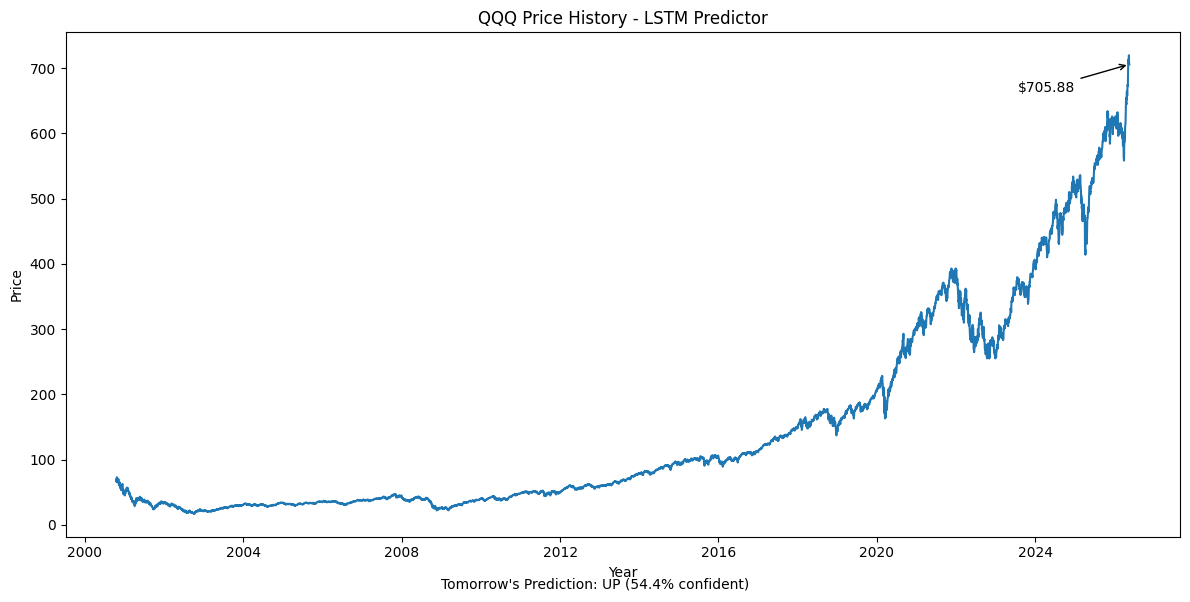

In [10]:
# Graphing
# Get last price
last_price = float(df["Close"].iloc[-1])

# Get LSTM prediction for tomorrow
model_lstm.eval()
with torch.no_grad():
    last_sequence = X_test_t[-1].unsqueeze(0)
    output = model_lstm(last_sequence)
    prediction = torch.argmax(output, dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][prediction].item()

direction = "UP" if prediction == 1 else "DOWN"

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Close"])
plt.title("QQQ Price History - LSTM Predictor")
plt.xlabel("Year")
plt.ylabel("Price")

plt.annotate(
    f"${last_price:.2f}",
    xy=(df.index[-1], last_price),
    xytext=(-80, -20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.figtext(0.5, 0.01,
    f"Tomorrow's Prediction: {direction} ({confidence*100:.1f}% confident)",
    ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Price History
# 2026
May 11 - Closing Price: $712.370300, Prediction for Tomorrow 61.9% UP w Test Acc: 55.49%   

May 12 - Closing Price: $707.239990, Prediction for Tomorrow 55.4% UP w Test Acc: 55.73%   
        Yesterday's prediction was wrong, prices went DOWN ~$5

May 13 - Closing Price: $714.710022, Prediction for Tomorrow 55.6% UP w Test Acc: 55.61%:   
        Yesterday's prediction was correct, prices went UP ~$7

May 14 - Closing Price: $722.030029, Prediction for Tomorrow 59.6% UP w Test Acc: 55.61%:   
        Yesterday's prediction was correct, prices went UP ~$8

May 15 - Did not record   

May 16 - Weekend, Market closed   

May 17 - Weekend, Market closed   

May 18 - Closing Price: $705.880005, Prediction for Tomorrow 54.4% UP w Test Acc: 55.37%:
